In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
!pip install kaggle


In [3]:
import os
import json

# Replace with your actual values
kaggle_username = "jayanthprathipati"
kaggle_key = "KGAT_0d737b4433e183b7c31d535ccb31a583"

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

with open(os.path.join(kaggle_dir, "kaggle.json"), "w") as f:
    json.dump({
        "username": kaggle_username,
        "key": kaggle_key
    }, f)

os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 600)

print("Kaggle API configured successfully!")


Kaggle API configured successfully!


In [4]:

!kaggle datasets download -d andrewmvd/face-mask-detection
!unzip face-mask-detection.zip


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:00<00:00, 523MB/s]
100% 398M/398M [00:00<00:00, 615MB/s]
Archive:  face-mask-detection.zip
  inflating: annotations/maksssksksss0.xml  
  inflating: annotations/maksssksksss1.xml  
  inflating: annotations/maksssksksss10.xml  
  inflating: annotations/maksssksksss100.xml  
  inflating: annotations/maksssksksss101.xml  
  inflating: annotations/maksssksksss102.xml  
  inflating: annotations/maksssksksss103.xml  
  inflating: annotations/maksssksksss104.xml  
  inflating: annotations/maksssksksss105.xml  
  inflating: annotations/maksssksksss106.xml  
  inflating: annotations/maksssksksss107.xml  
  inflating: annotations/maksssksksss108.xml  
  inflating: annotations/maksssksksss109.xml  
  inflating: annotations/maksssksksss11.xml  
  inflating: annotations/maksssksksss110.xml  
  inflating: annotations/maksssksksss111.xml  
  inflating: annotations/maksssksksss112.xml  
  

In [27]:
import os

print("Images exist:", os.path.exists(images_dir))
print("Annotations exist:", os.path.exists(annotations_dir))

print("Images count:", len(os.listdir(images_dir)) if os.path.exists(images_dir) else "No folder")
print("Annotations count:", len(os.listdir(annotations_dir)) if os.path.exists(annotations_dir) else "No folder")


Images exist: True
Annotations exist: True
Images count: 853
Annotations count: 853


In [29]:
from tqdm import tqdm
import xml.etree.ElementTree as ET


images_dir = '/content/images'
annotations_dir = '/content/annotations'
output_dir = '/content/processed_dataset'
categories = ['with_mask', 'without_mask', 'mask_weared_incorrect']

# Create folders
for category in categories:
    os.makedirs(os.path.join(output_dir, category), exist_ok=True)

print("Starting the Crop & Sort Machine...")

# Loop through all XML files
for xml_file in tqdm(os.listdir(annotations_dir)):
    try:
        # Read the XML map
        tree = ET.parse(os.path.join(annotations_dir, xml_file))
        root = tree.getroot()
        filename = root.find('filename').text
        image_path = os.path.join(images_dir, filename)

        img = cv2.imread(image_path)
        if img is None: continue

        # Find objects (faces) in the image
        for obj in root.findall('object'):
            label = obj.find('name').text
            if label in categories:
                # Get coordinates
                bndbox = obj.find('bndbox')
                xmin = int(bndbox.find('xmin').text)
                ymin = int(bndbox.find('ymin').text)
                xmax = int(bndbox.find('xmax').text)
                ymax = int(bndbox.find('ymax').text)

                # CROP the face
                face = img[ymin:ymax, xmin:xmax]

                # Resize and Save
                if face.size != 0:
                    face = cv2.resize(face, (224, 224))
                    save_path = os.path.join(output_dir, label, f"{filename}_{xmin}.jpg")
                    cv2.imwrite(save_path, face)
    except Exception as e:
        print(e)
        pass

print("Dataset is fixed and sorted!")


Starting the Crop & Sort Machine...


100%|██████████| 853/853 [00:12<00:00, 68.12it/s]

Dataset is fixed and sorted!


In [30]:
with_mask_files=os.listdir("/content/processed_dataset/with_mask")
without_mask_files=os.listdir("/content/processed_dataset/without_mask")
incorrect_mask_files=os.listdir("/content/processed_dataset/mask_weared_incorrect")

In [31]:
len(with_mask_files)

3195

In [32]:
len(without_mask_files)

708

In [33]:
len(incorrect_mask_files)

123

In [36]:
with_mask_label=[1]*len(with_mask_files)
without_mask_label=[0]*len(without_mask_files)
incorrect_mask_label=[0]*len(incorrect_mask_files)
labels=with_mask_label+without_mask_label+incorrect_mask_label

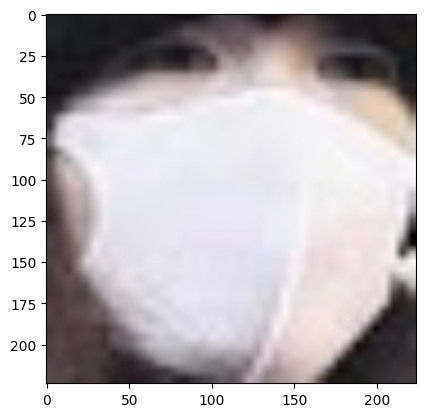

In [37]:
img=mpimg.imread('/content/processed_dataset/with_mask/maksssksksss0.png_185.jpg')
plt.imshow(img)

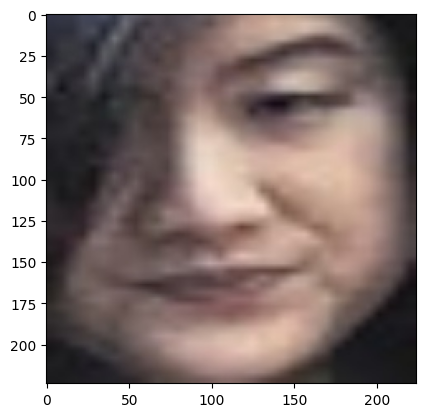

In [38]:
img=mpimg.imread('/content/processed_dataset/without_mask/maksssksksss0.png_325.jpg')
plt.imshow(img)

Image processing

In [39]:
with_mask_path = "/content/processed_dataset/with_mask"
data = []

for img_file in with_mask_files:
    img_path = with_mask_path + "/" + str(img_file)
    image = Image.open(img_path)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)


without_mask_path = "/content/processed_dataset/without_mask"
for img_file in without_mask_files:
    img_path = without_mask_path + "/" + str(img_file)
    image = Image.open(img_path)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)


incorrect_mask_path = "/content/processed_dataset/mask_weared_incorrect"
for img_file in incorrect_mask_files:
    img_path = incorrect_mask_path + "/" + str(img_file)
    image = Image.open(img_path)
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)


In [40]:
len(data)

4026

In [41]:
data[0].shape

(128, 128, 3)

Converting image list and label list to numpy arrays

In [42]:
X=np.array(data)
Y=np.array(labels)

In [43]:
print(X.shape)
print(Y.shape)

(4026, 128, 128, 3)
(4026,)


Train test split

In [44]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2,random_state=2)


In [45]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

Building resnet-50 model

In [46]:
import tensorflow as tf

from tensorflow import keras

In [47]:
num_classes = 2

In [48]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def resnet_block(x, filters, downsample=False):
    identity = x

    # First block
    x = Conv2D(filters=filters, kernel_size=(3, 3), strides=(1 if not downsample else 2, 1 if not downsample else 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second block
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    # Skip connection
    if downsample:
        identity = Conv2D(filters=filters, kernel_size=(1, 1), strides=(2, 2), padding='valid')(identity)
        identity = BatchNormalization()(identity)

    x = Add()([x, identity])
    x = Activation('relu')(x)
    return x

# Input layer
input_layer = Input(shape=(128, 128, 3))

# Convolutional layers
x = Conv2D(64, kernel_size=(7, 7), strides=(2, 2), padding='same')(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = resnet_block(x, filters=64)
x = resnet_block(x, filters=64)
x = resnet_block(x, filters=64)

x = resnet_block(x, filters=128, downsample=True)
x = resnet_block(x, filters=128)
x = resnet_block(x, filters=128)
x = resnet_block(x, filters=128)

x = resnet_block(x, filters=256, downsample=True)
x = resnet_block(x, filters=256)
x = resnet_block(x, filters=256)
x = resnet_block(x, filters=256)
x = resnet_block(x, filters=256)
x = resnet_block(x, filters=256)

x = resnet_block(x, filters=512, downsample=True)
x = resnet_block(x, filters=512)
x = resnet_block(x, filters=512)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Fully connected layers
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer for binary classification (mask or no mask)
output_layer = Dense(num_classes, activation='sigmoid')(x)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model with an appropriate optimizer and loss function
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


In [49]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])


In [50]:
history=model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 90s 495ms/step - acc: 0.7978 - loss: 0.5475 - val_acc: 0.7826 - val_loss: 457.9246
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - acc: 0.8883 - loss: 0.4682 - val_acc: 0.4379 - val_loss: 1.4307
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - acc: 0.8884 - loss: 0.2867 - val_acc: 0.5186 - val_loss: 1.6575
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - acc: 0.9156 - loss: 0.2592 - val_acc: 0.6211 - val_loss: 1.1309
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - acc: 0.9176 - loss: 0.2421 - val_acc: 0.3168 - val_loss: 3.4740


Model evaluation

In [51]:
loss,accuracy=model.evaluate(X_test_scaled, Y_test)
print("Test Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - acc: 0.3374 - loss: 3.1249
Test Accuracy: 0.3374689817428589


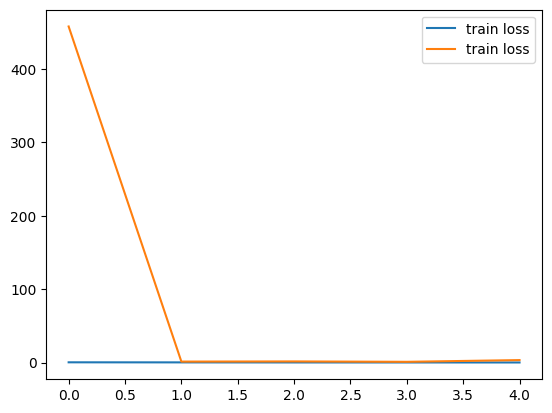

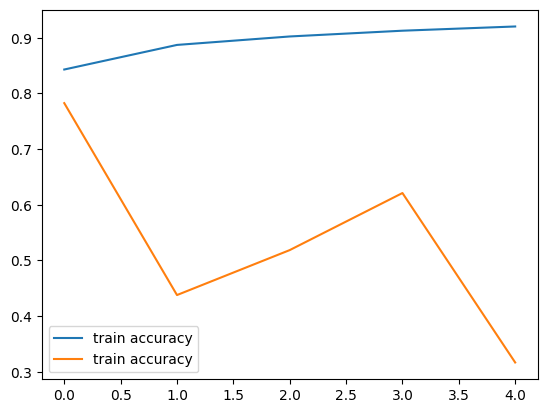

In [52]:
h=history
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='train loss')
plt.legend()
plt.show()

plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='train accuracy')
plt.legend()
plt.show()

Predictive system

In [ ]:
input_image_path=input("Path of image to predict")

input_image=cv2.imread(input_image_path)
cv2_imshow(input_image)
input_image_resized=cv2.resize(input_image, (128,128))
input_image_scaled=input_image_resized/255
input_image_reshaped=np.reshape(input_image_scaled,(1,128,128,3))
input_prediction=model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label=np.argmax(input_prediction)
print(input_pred_label)

if(input_pred_label==1):
  print("Person in image is waering mask")
else:
  print("No mask detetcted")